In [1]:
import jpype
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
from typing import List, Tuple

# Запуск JVM
jpype.startJVM(classpath=[".."])

# Импорт Java-классов
KnapsackProblem = jpype.JClass("utils.knapsack.KnapsackProblem")
Item = jpype.JClass("utils.knapsack.KnapsackProblem$Item")
BruteForceKnapsack = jpype.JClass("utils.knapsack.KnapsackProblem$BruteForceKnapsack")
GreedyKnapsack = jpype.JClass("utils.knapsack.KnapsackProblem$GreedyKnapsack")

ArrayList = jpype.JClass("java.util.ArrayList")

In [3]:
def generate_random_items(n: int, max_weight: int = 20, max_value: int = 100) -> ArrayList:
    items = ArrayList()
    for i in range(n):
        weight = random.randint(1, max_weight)
        value = random.randint(1, max_value)
        items.add(Item(i + 1, weight, value))
    return items

def test_algorithms(n_values: List[int], max_weight: int = 50, iterations: int = 5):
    results = []
    
    for n in n_values:
        print(f"\nТестирование для n = {n}")
        bf_times = []
        bf_values = []
        greedy_times = []
        greedy_values = []
        value_ratios = []  # Отношение значения жадного алгоритма к полному перебору
        
        for _ in range(iterations):
            items = generate_random_items(n)
            
            # Тестируем полный перебор
            bf_solver = BruteForceKnapsack()
            bf_result = bf_solver.solve(items, max_weight)
            bf_times.append(bf_result.executionTime)
            bf_values.append(bf_result.totalValue)
            
            # Тестируем жадный алгоритм
            greedy_solver = GreedyKnapsack()
            greedy_result = greedy_solver.solve(items, max_weight)
            greedy_times.append(greedy_result.executionTime)
            greedy_values.append(greedy_result.totalValue)
            
            # Вычисляем отношение значений
            if bf_result.totalValue > 0:
                value_ratios.append(greedy_result.totalValue / bf_result.totalValue)
        
        results.append({
            'n': n,
            'bf_mean_time': np.mean(bf_times),
            'bf_std_time': np.std(bf_times),
            'bf_mean_value': np.mean(bf_values),
            'greedy_mean_time': np.mean(greedy_times),
            'greedy_std_time': np.std(greedy_times),
            'greedy_mean_value': np.mean(greedy_values),
            'value_ratio': np.mean(value_ratios)
        })
    
    return results

def plot_time_comparison(results: List[dict]):
    n_values = [r['n'] for r in results]
    bf_times = [r['bf_mean_time'] for r in results]
    bf_stds = [r['bf_std_time'] for r in results]
    greedy_times = [r['greedy_mean_time'] for r in results]
    greedy_stds = [r['greedy_std_time'] for r in results]
    
    plt.figure(figsize=(12, 6))
    plt.errorbar(n_values, bf_times, yerr=bf_stds, fmt='o-', label='Полный перебор')
    plt.errorbar(n_values, greedy_times, yerr=greedy_stds, fmt='o-', label='Жадный алгоритм')
    plt.xlabel('Количество предметов (n)')
    plt.ylabel('Время выполнения (нс)')
    plt.title('Сравнение времени выполнения алгоритмов')
    plt.legend()
    plt.grid(True)
    plt.yscale('log')
    plt.show()

def plot_value_ratio(results: List[dict]):
    n_values = [r['n'] for r in results]
    ratios = [r['value_ratio'] for r in results]
    
def test_example():
    # Пример из условия или тестовый пример
    items = ArrayList()
    items.add(Item(1, 2, 3))   # Предмет 1: вес=2, стоимость=3
    items.add(Item(2, 3, 4))   # Предмет 2: вес=3, стоимость=4
    items.add(Item(3, 4, 5))   # Предмет 3: вес=4, стоимость=5
    items.add(Item(4, 5, 6))   # Предмет 4: вес=5, стоимость=6
    
    max_weight = 10
    
    print("\nТестовый пример:")
    print(f"Максимальный вес рюкзака: {max_weight}")
    print("\nДоступные предметы:")
    for i in range(items.size()):
        item = items.get(i)
        print(f"Предмет {item.id}: вес = {item.weight}, стоимость = {item.value}")
    
    print("\nРешение полным перебором:")
    bf_solver = BruteForceKnapsack()
    bf_result = bf_solver.solve(items, max_weight)
    print(f"Общая стоимость: {bf_result.totalValue}")
    print(f"Общий вес: {bf_result.totalWeight}")
    print("Выбранные предметы:")
    for item in bf_result.selectedItems:
        print(f"Предмет {item.id}: вес = {item.weight}, стоимость = {item.value}")
    print(f"Время выполнения: {bf_result.executionTime} нс")
    
    print("\nРешение жадным алгоритмом:")
    greedy_solver = GreedyKnapsack()
    greedy_result = greedy_solver.solve(items, max_weight)
    print(f"Общая стоимость: {greedy_result.totalValue}")
    print(f"Общий вес: {greedy_result.totalWeight}")
    print("Выбранные предметы:")
    for item in greedy_result.selectedItems:
        print(f"Предмет {item.id}: вес = {item.weight}, стоимость = {item.value}")
    print(f"Время выполнения: {greedy_result.executionTime} нс")

def main():
    # Тестирование примера
    test_example()
    
    # Тестирование производительности
    # Для полного перебора используем небольшие значения n
    n_values_small = [5, 10, 15, 20]
    print("\nТестирование производительности для небольших входных данных:")
    results_small = test_algorithms(n_values_small)
    
    # Для сравнения времени выполнения
    plot_time_comparison(results_small)
    
    # Для анализа качества жадного алгоритма
    plot_value_ratio(results_small)
    
    # Тестирование жадного алгоритма на больших входных данных
    n_values_large = [100, 500, 1000, 5000]
    print("\nТестирование производительности жадного алгоритма для больших входных данных:")
    results_large = []
    
    for n in n_values_large:
        print(f"\nТестирование для n = {n}")
        times = []
        values = []
        
        for _ in range(5):
            items = generate_random_items(n)
            solver = GreedyKnapsack()
            result = solver.solve(items, 1000)  # Увеличиваем максимальный вес для больших наборов
            times.append(result.executionTime)
            values.append(result.totalValue)
        
        results_large.append({
            'n': n,
            'mean_time': np.mean(times),
            'std_time': np.std(times),
            'mean_value': np.mean(values)
        })
    
    # Вывод результатов в таблицы
    print("\nРезультаты для небольших входных данных:")
    df_small = pd.DataFrame(results_small)
    print(df_small.to_string(index=False))
    
    print("\nРезультаты для больших входных данных (только жадный алгоритм):")
    df_large = pd.DataFrame(results_large)
    print(df_large.to_string(index=False))


Тестовый пример:
Максимальный вес рюкзака: 10

Доступные предметы:
Предмет 1: вес = 2, стоимость = 3
Предмет 2: вес = 3, стоимость = 4
Предмет 3: вес = 4, стоимость = 5
Предмет 4: вес = 5, стоимость = 6

Решение полным перебором:
Общая стоимость: 13
Общий вес: 10
Выбранные предметы:
Предмет 1: вес = 2, стоимость = 3
Предмет 2: вес = 3, стоимость = 4
Предмет 4: вес = 5, стоимость = 6
Время выполнения: 1626600 нс

Решение жадным алгоритмом:
Общая стоимость: 12
Общий вес: 9
Выбранные предметы:
Предмет 1: вес = 2, стоимость = 3
Предмет 2: вес = 3, стоимость = 4
Предмет 3: вес = 4, стоимость = 5
Время выполнения: 452600 нс

Тестирование производительности для небольших входных данных:

Тестирование для n = 5

Тестирование для n = 10

Тестирование для n = 15

Тестирование для n = 20


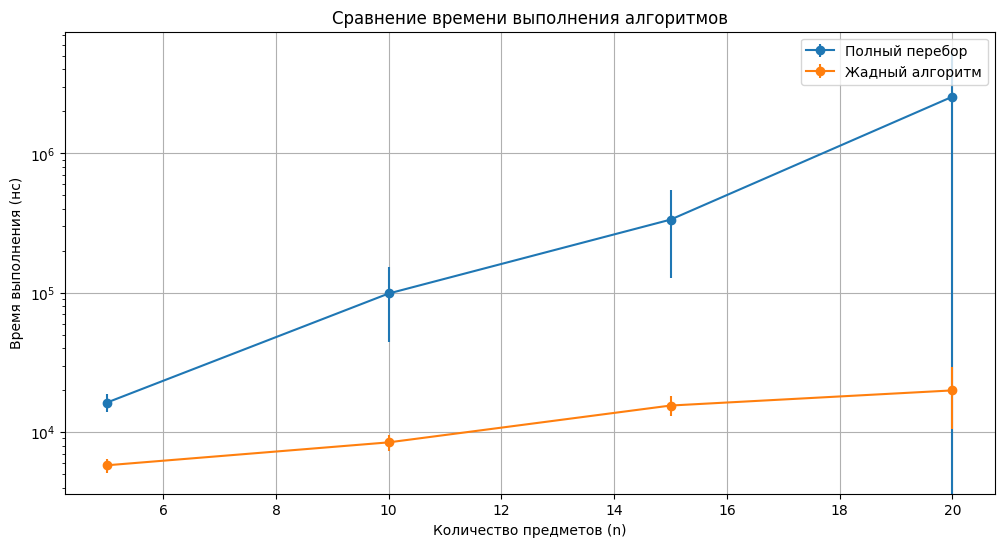


Тестирование производительности жадного алгоритма для больших входных данных:

Тестирование для n = 100

Тестирование для n = 500

Тестирование для n = 1000

Тестирование для n = 5000

Результаты для небольших входных данных:
 n  bf_mean_time  bf_std_time  bf_mean_value  greedy_mean_time  greedy_std_time  greedy_mean_value  value_ratio
 5       16280.0 2.457967e+03          226.8            5780.0       667.532771              222.8     0.981052
10       98580.0 5.445466e+04          384.4            8440.0      1114.629983              374.8     0.977114
15      333680.0 2.067010e+05          538.0           15500.0      2543.226297              533.4     0.991754
20     2538660.0 2.709491e+06          582.0           19900.0      9304.622507              577.0     0.991721

Результаты для больших входных данных (только жадный алгоритм):
   n  mean_time      std_time  mean_value
 100    74580.0  22264.446995      4884.8
 500   308860.0  18507.684890     12340.2
1000   471480.0  19866

In [4]:
main()